In [112]:
%load_ext autoreload
%autoreload 2
import jax
import pgx
from pgx.experimental import auto_reset, act_randomly
from twentyfortyeight import *
import jax.numpy as jnp
from matplotlib import pyplot as plt
import numpy as np
import equinox as eqx
import copy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [113]:
env_id = "2048"
env = pgx.make(env_id)
batch_size = 8192
eval_batch_size = 128

init = jax.jit(jax.vmap(env.init))
step_fn = jax.jit(jax.vmap(auto_reset(env.step, env.init)))
eval_init = jax.jit(jax.vmap(env.init))
eval_step_fn = jax.jit(jax.vmap(env.step))

key = jax.random.key(0)
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, batch_size)

In [ ]:
timesteps = 16
minibatches = 128
epochs = 10000
eval_every = 100

obs_wrapper = ToDtype(float, TransposeObservation((2, 0, 1)))

key, subkey1, subkey2 = jax.random.split(key, 3)
conv1 = Conv2048(subkey1)
policy_network = ConvNetwork(conv1, MLP(conv1.output_dim, 4, subkey2))
key, subkey1, subkey2 = jax.random.split(key, 3)
conv2 = Conv2048(subkey1)
value_network = ConvNetwork(conv2, MLP(conv2.output_dim, 1, subkey2))
ppo_network = model = PPONetwork(policy_network, value_network)

key, subkey = jax.random.split(key)
eval_step = make_eval_step(eval_init, eval_step_fn, eval_batch_size, subkey, obs_wrapper)
state = init(keys)
state, _, _ = collect_trajectory(ppo_network, step_fn, state, state.observation, key, 100, obs_wrapper=obs_wrapper)
key, subkey = jax.random.split(key)
optim = optimizer = optax.chain(optax.clip_by_global_norm(0.5), optax.adam(1e-4, eps=1e-5))
grad_step = make_grad_step(ppo_network, ppo_loss, optim, subkey, minibatches)

In [ ]:
losses = []
policy_losses = []
entropy_losses = []
train_rewards = []
eval_rewards = []
eval_timesteps = []
for i in range(epochs + 1):
    if i % eval_every == 0:
        eval_reward, eval_length = eval_step(ppo_network)
        print(f"epoch {i}: reward: {eval_reward}, episode length: {eval_length}")
        eval_rewards.append(eval_reward)
        eval_timesteps.append(eval_length)
    state, final_obs, traj = collect_trajectory(ppo_network, step_fn, state, state.observation, key, timesteps, obs_wrapper=obs_wrapper)
    (loss, metrics), ppo_network = grad_step(ppo_network, traj, final_obs, 0.99, 0.95, 0.2, 1, 0.0)
    losses.append(np.array(loss))
    policy_losses.append(np.array(metrics['policy_loss']))
    entropy_losses.append(np.array(metrics['entropy_loss']))
    train_rewards.append(np.array(jnp.sum(traj.rewards) / jnp.sum(traj.dones)))


epoch 0: reward: 2028.03125, episode length: 351
epoch 2: reward: 1653.5625, episode length: 334
epoch 4: reward: 2293.5625, episode length: 513
epoch 6: reward: 2299.375, episode length: 540
epoch 8: reward: 2480.1875, episode length: 480
epoch 10: reward: 2640.34375, episode length: 511
epoch 12: reward: 2583.3125, episode length: 581
epoch 14: reward: 2633.875, episode length: 497
epoch 16: reward: 2729.46875, episode length: 502
epoch 18: reward: 2644.625, episode length: 425
epoch 20: reward: 3229.09375, episode length: 519


ValueError: x and y must have same first dimension, but have shapes (22,) and (11,)

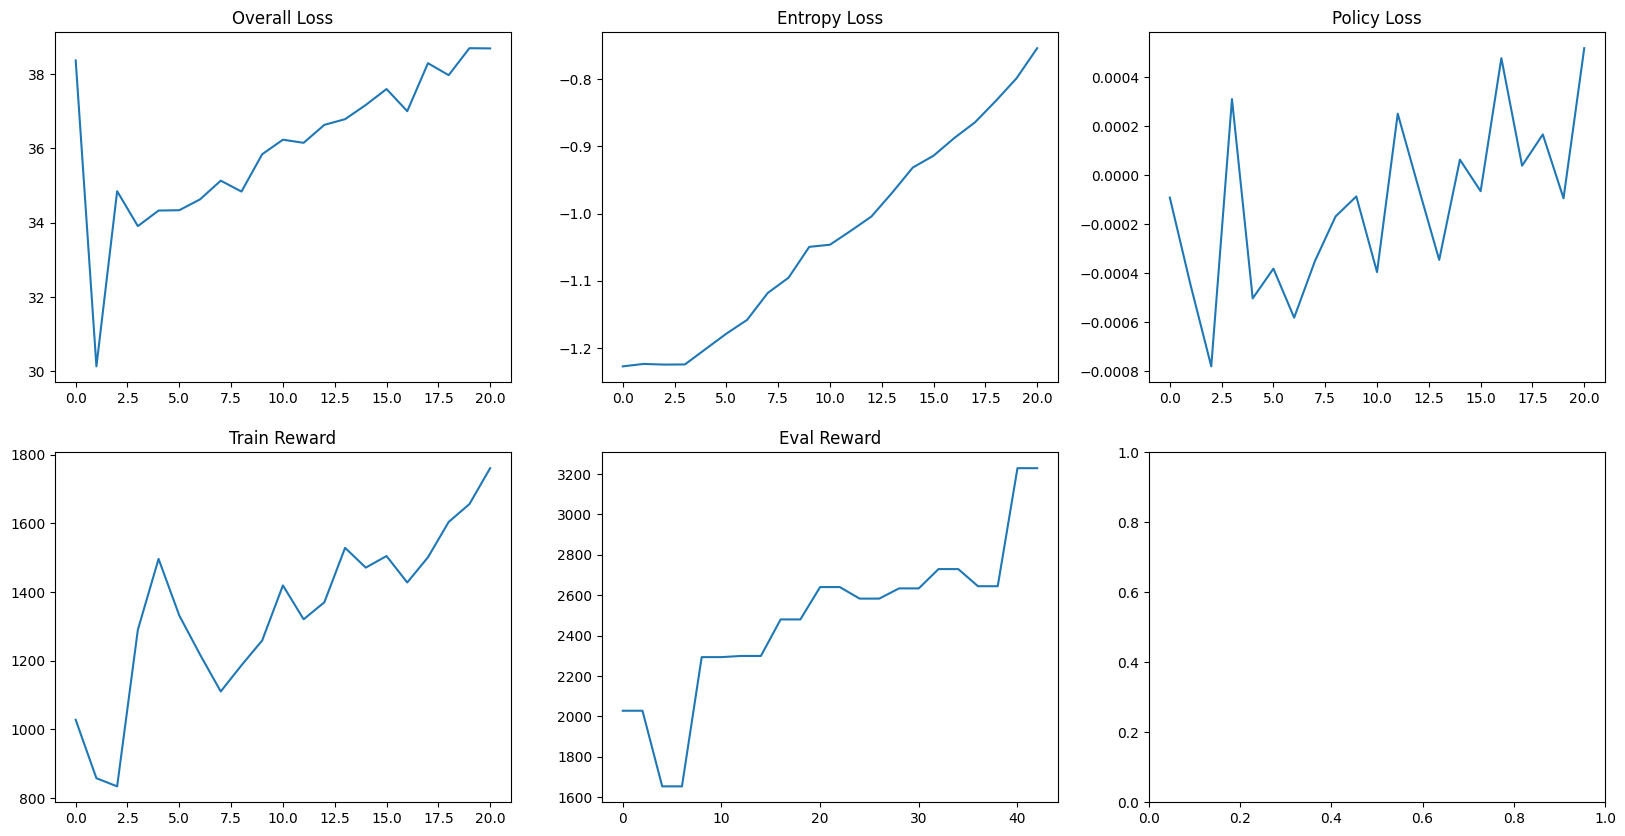

In [ ]:
fig, axs = plt.subplots(2, 3)
fig.set_figwidth(20)
fig.set_figheight(10)
axs[0, 0].plot(losses)
axs[0, 0].set_title("Overall Loss")
axs[0, 1].plot(entropy_losses)
axs[0, 1].set_title("Entropy Loss")
axs[0, 2].plot(policy_losses)
axs[0, 2].set_title("Policy Loss")
axs[1, 0].plot(train_rewards)
axs[1, 0].set_title("Train Reward")
eval_axis = np.arange(len(eval_rewards)) * eval_every
axs[1, 1].plot(eval_axis, eval_rewards)
axs[1, 1].set_title("Eval Reward")
axs[1, 2].plot(eval_axis, eval_timesteps)
axs[1, 2].set_title("Eval Episode Length")
print(metrics)

In [ ]:
eval_reward

Array(45175.71, dtype=float32)

In [ ]:
jax.tree_util.tree_map(jnp.mean, (loss, metrics))

(Array(78.56743, dtype=float32),
 {'entropy_loss': Array(-0.2127982, dtype=float32),
  'policy_loss': Array(0.00107106, dtype=float32),
  'value_loss': Array(78.56849, dtype=float32)})

In [ ]:
import equinox as eqx

eqx.tree_serialise_leaves("ppo_network_conv.eqx", ppo_network)

In [ ]:
# ppo_network = eqx.tree_deserialise_leaves(f"ppo_network_{env_id}.eqx", ppo_network)

In [ ]:
env = pgx.make(env_id)
batch_size = 4

init = jax.jit(jax.vmap(env.init))  # vectorize and JIT-compile
eval_step = jax.jit(jax.vmap(env.step))

key = jax.random.key(42)
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, batch_size)

states = []
state = init(keys)
states.append(state)
entropy_losses = 0

while not (state.terminated | state.truncated).all():
    key, subkey, subkey2 = jax.random.split(key, 3)
    action, _ = ppo_network.policy_fn(obs_wrapper(state.observation), state.legal_action_mask, subkey, True)
    keys = jax.random.split(subkey2, batch_size)
    state = step_fn(state, action, keys)
    states.append(state)
    entropy_losses += jnp.mean(state.rewards)

In [ ]:
pgx.save_svg_animation(states, f"{env_id}.svg", frame_duration_seconds=0.05)

In [ ]:
entropy_losses

Array(58416., dtype=float32)

In [ ]:
state

State(current_player=Array([0, 0, 0, 0], dtype=int32), observation=Array([[[[False, False,  True, ..., False, False, False],
         [False,  True, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False,  True, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False,  True, False, ..., False, False, False],
         [False, False,  True, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]],


       [[[False, False,  True, ..., False, False, False],
         [False,  True, False, ..., False, False, False],
         [False, False,  True, ..., False, False, False],
         [False,  True, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False,  True, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]],


       [[[False, False, False, ..., False, False, False],
         [False, False,  True, ..., False, False, False],
         [False,  True, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False,  True, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False,  True, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False,  True, False, ..., False, False, False]]],


       [[[False,  True, False, ..., False, False, False],
         [False, False,  True, ..., False, False, False],
         [False,  True, False, ..., False, False, False],
         [False, False,  True, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False,  True, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False,  True, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]]], dtype=bool), rewards=Array([[0.],
       [0.],
       [0.],
       [0.]], dtype=float32), terminated=Array([ True,  True,  True,  True], dtype=bool), truncated=Array([False, False, F